## Project Responsible AI Part 1
#### Topic: Applying Differential Privacy on Input Data and Model.

By:
* Hamza Khalid 24PGAI0079
* Soham Sanyal 24PGAI0055
* Kishnu Shrivastava 24PGAI0042

Note: this notebook has been coded using code references from:
* https://github.com/srayagarwal/JIO_RAI/
* ChatGPT


We have to first encode the categorical data:

In [5]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load your dataset
df_normal = pd.read_csv('ibm_hr_data.csv')

# Initialize LabelEncoder
label_encoders = {}

# Encode categorical columns
for col in df_normal.columns:
    if df_normal[col].dtype == 'object':
        label_encoders[col] = LabelEncoder()
        df_normal[col] = label_encoders[col].fit_transform(df_normal[col])

# Save the encoded dataset to a new CSV file
df_normal.to_csv('ibm_hr_data_encoded.csv', index=False)
df_normal.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


Finding the important features for building the model:

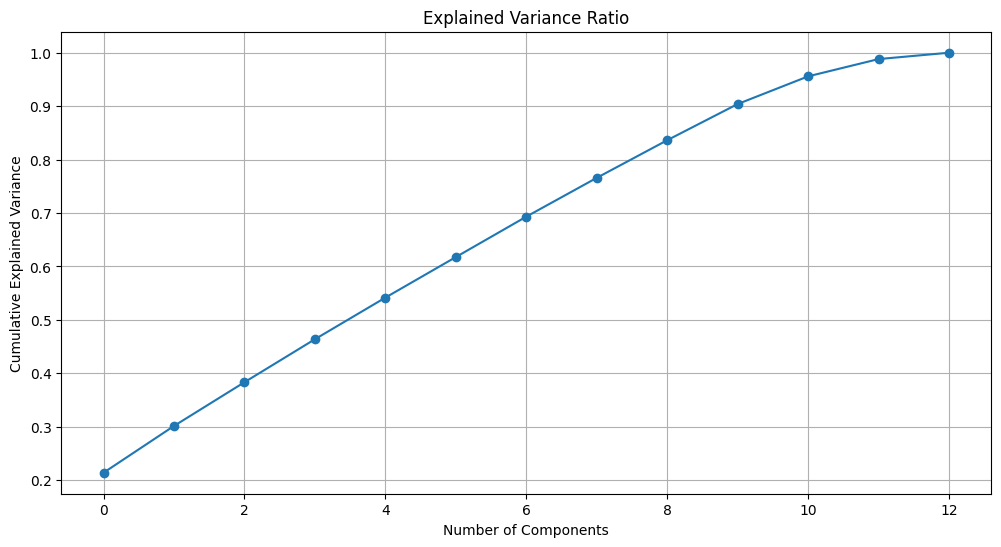

Component 1: TotalWorkingYears
Component 2: MaritalStatus
Component 3: DistanceFromHome
Component 4: DailyRate
Component 5: PercentSalaryHike
Component 6: MonthlyRate
Component 7: EducationField
Component 8: JobRole
Component 9: Gender
Component 10: MaritalStatus
Component 11: Age
Component 12: MonthlyIncome
Component 13: TotalWorkingYears


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

df_encoded = pd.read_csv('ibm_hr_data_encoded.csv')

# Assuming 'data' is your DataFrame with the selected_features
selected_features = ['MonthlyRate', 'DailyRate', 'MonthlyIncome', 'HourlyRate', 'PercentSalaryHike',
                     'DistanceFromHome', 'Age', 'TotalWorkingYears', 'YearsAtCompany', 'JobRole',
                     'Gender', 'MaritalStatus', 'EducationField']

# Selecting the features from the dataset
X = df_encoded[selected_features]

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plotting the explained variance ratio
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Get the most important features for each component
num_top_features = 1  # Number of top features to show for each component
top_features = []
for component in pca.components_:
    top_feature_indices = np.argsort(np.abs(component))[-num_top_features:]
    top_features.append([selected_features[i] for i in top_feature_indices])

# Print the top features for each component
for i, features in enumerate(top_features):
    print(f"Component {i+1}: {', '.join(features)}")


In [7]:
# a function to nicely evaluate all the metrics:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from sklearn import metrics



def evaluate(model, X_test, y_test, *args):
    
    if args:
        for arg in args:
            print("#### value of epsilon : {arg} ####".format(arg=arg))
            y_pred = model.predict(X_test)
            
            # Classification Report
            print("Classification Report:")
            print(classification_report(y_test, y_pred))
            
            # AUC
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_pred_proba)
            print(f"AUC: {auc:.4f}")

            # Confusion matrix
            print("\nConfusion Matrix:")
            confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
            cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
            cm_display.plot()
            plt.show()

            # F1 Score
            f1 = f1_score(y_test, y_pred)
            print(f"F1 Score: {f1:.4f}")

            # True Positive Rate (Recall)
            recall = recall_score(y_test, y_pred)
            print(f"True Positive Rate (Recall): {recall:.4f}")

            # True Negative Rate
            tnr = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
            print(f"True Negative Rate (TNR): {tnr:.4f}")

            # False Positive Rate
            fpr = confusion_matrix[0, 1] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
            print(f"False Positive Rate (FPR): {fpr:.4f}")

            epsilon = arg
            accuracy = accuracy_score(y_test, y_pred)
            return epsilon, accuracy
        
    else:
        
        y_pred = model.predict(X_test)
        
        # Classification Report
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        
        # AUC
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"AUC: {auc:.4f}")

        # Confusion matrix
        print("\nConfusion Matrix:")
        confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
        cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
        cm_display.plot()
        plt.show()

        # F1 Score
        f1 = f1_score(y_test, y_pred)
        print(f"F1 Score: {f1:.4f}")

        # True Positive Rate (Recall)
        recall = recall_score(y_test, y_pred)
        print(f"True Positive Rate (Recall): {recall:.4f}")

        # True Negative Rate
        tnr = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
        print(f"True Negative Rate (TNR): {tnr:.4f}")

        # False Positive Rate
        fpr = confusion_matrix[0, 1] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
        print(f"False Positive Rate (FPR): {fpr:.4f}")

        
        
        
        
    # ROC curve and AUC
    # y_pred_proba = model.predict_proba(X_test)[:, 1]
    # fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    # auc = roc_auc_score(y_test, y_pred_proba)

    # plt.figure(figsize=(8, 6))
    # plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    # plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title('ROC Curve')
    # plt.legend()
    # plt.show()




### Diffential Privacy in: Model-> with DP , Input Data-> with DP

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.1 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       236
           1       0.27      0.12      0.17        58

    accuracy                           0.76       294
   macro avg       0.54      0.52      0.51       294
weighted avg       0.70      0.76      0.72       294

AUC: 0.5963

Confusion Matrix:


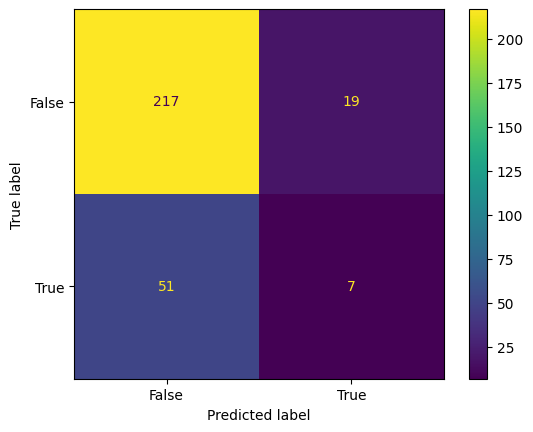

F1 Score: 0.1667
True Positive Rate (Recall): 0.1207
True Negative Rate (TNR): 0.9195
False Positive Rate (FPR): 0.0805


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.2 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.50      0.02      0.03        58

    accuracy                           0.80       294
   macro avg       0.65      0.51      0.46       294
weighted avg       0.74      0.80      0.72       294

AUC: 0.5452

Confusion Matrix:


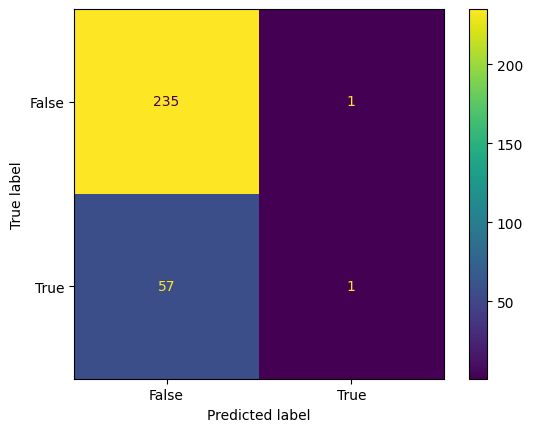

F1 Score: 0.0333
True Positive Rate (Recall): 0.0172
True Negative Rate (TNR): 0.9958
False Positive Rate (FPR): 0.0042


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.30000000000000004 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.45       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.5346

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

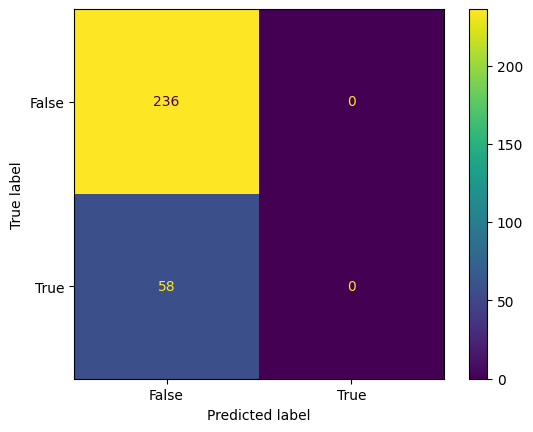

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 1.0000
False Positive Rate (FPR): 0.0000


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.4 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.45       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.5479

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

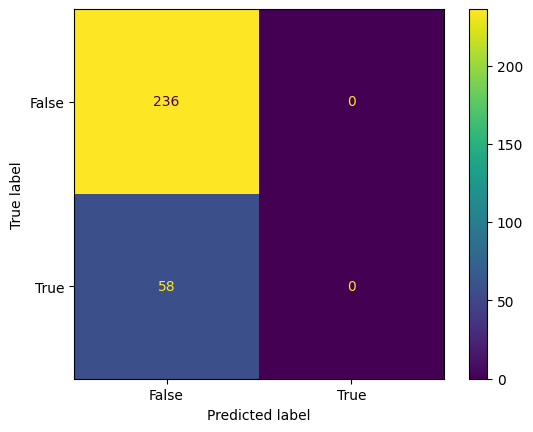

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 1.0000
False Positive Rate (FPR): 0.0000


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.5 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.44       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.5736

Confusion Matrix:


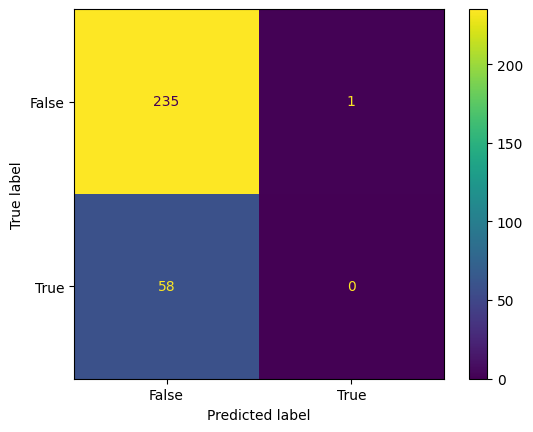

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 0.9958
False Positive Rate (FPR): 0.0042


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.6 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.44       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.5775

Confusion Matrix:


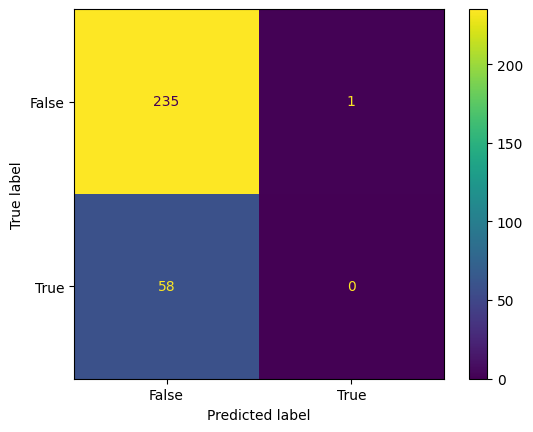

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 0.9958
False Positive Rate (FPR): 0.0042


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.7000000000000001 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.45       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.5848

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

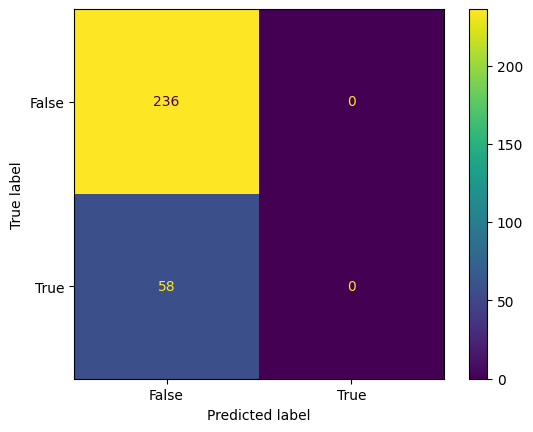

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 1.0000
False Positive Rate (FPR): 0.0000


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.8 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.45       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.5987

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

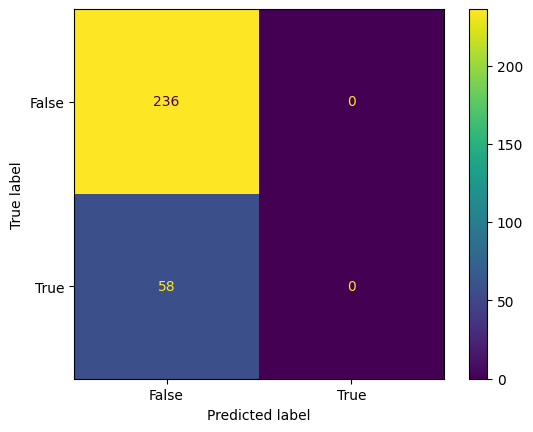

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 1.0000
False Positive Rate (FPR): 0.0000


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify the prediction classes for model.
  warnings.warn("Classes have not been specified and will be calculated on the data provided. This will "


#### value of epsilon : 0.9 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.45       294
weighted avg       0.64      0.80      0.71       294

AUC: 0.5064

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

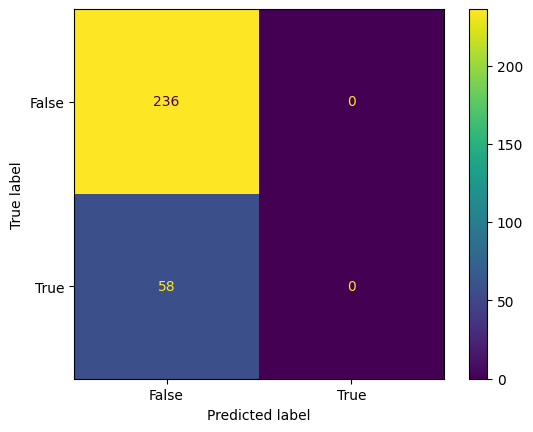

F1 Score: 0.0000
True Positive Rate (Recall): 0.0000
True Negative Rate (TNR): 1.0000
False Positive Rate (FPR): 0.0000


In [8]:
import diffprivlib
from diffprivlib.models import RandomForestClassifier as RFC_dp
from numpy import arange
from sklearn.model_selection import train_test_split


df_encoded_DP = pd.read_csv('ibm_hr_data_encoded_DP.csv')
selected_features = ['TotalWorkingYears', 'MaritalStatus', 'DistanceFromHome', 'DailyRate',
                     'PercentSalaryHike', 'MonthlyRate', 'EducationField', 'JobRole', 'Gender',
                     'Age', 'MonthlyIncome']
X_DP = df_encoded_DP[selected_features]
y_DP = df_encoded_DP['Attrition']  # Assuming 'Attrition' is the target variable




# Splitting the dataset into training and testing sets
X_train_DP, X_test_DP, y_train_DP, y_test_DP = train_test_split(X_DP, y_DP, test_size=0.2, random_state=69)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_DP)
X_test_scaled = scaler.transform(X_test_DP)

# Balance the classes manually
class_counts = y_train_DP.value_counts()
class_weights = {0: len(y_train_DP) / (2 * class_counts[0]), 1: len(y_train_DP) / (2 * class_counts[1])}

for epsilon in arange(0.1, 1.0, 0.1):
    # Creating and training the random forest classifier
    model_DP_data_DP = RFC_dp(n_estimators=100, random_state=30,  epsilon=epsilon, n_jobs=1, verbose=0, accountant=None)
    model_DP_data_DP.fit(X_train_DP, y_train_DP)

    # Evaluate the model
    evaluate(model_DP_data_DP, X_test_DP, y_test_DP, epsilon)